# **Import Everything**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import math
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score,
                             confusion_matrix,
                             classification_report)

print('Everything is imported boss')

Everything is imported boss


# **Data Explration**

## **Load the Data**

In [2]:
file_path = input("Enter the File Path Baby: ")
df = pd.read_csv(file_path)
print('Data Loaded Baby')

Data Loaded Baby


## **Exploration**

In [3]:
print(f'The dataset have {df.shape[0]} Rows and {df.shape[1]} columns with {df.duplicated().sum()} Duplicates')

The dataset have 5040 Rows and 9 columns with 40 Duplicates


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5040 entries, 0 to 5039
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   glucose            4937 non-null   str    
 1   bmi                4940 non-null   float64
 2   age                4940 non-null   float64
 3   blood_pressure     4940 non-null   float64
 4   insulin            4940 non-null   float64
 5   skin_thickness     4939 non-null   float64
 6   pregnancies        4940 non-null   float64
 7   diabetes_pedigree  4939 non-null   float64
 8   diabetic           5040 non-null   int64  
dtypes: float64(7), int64(1), str(1)
memory usage: 378.2 KB


In [5]:
df.sample(10)

,glucose,bmi,age,blood_pressure,insulin,skin_thickness,pregnancies,diabetes_pedigree,diabetic
4778,162.8,38.1,63.0,63.0,29.3,12.8,0.0,0.346,1
472,132.9,34.1,76.0,114.0,250.2,13.7,1.0,1.717,1
1298,137.8,25.5,30.0,114.0,129.6,40.9,5.0,1.063,1
3464,119.4,20.8,22.0,62.0,120.3,11.6,3.0,2.149,0
3970,176.2,25.1,53.0,61.0,177.7,17.3,NaN,1.279,1
74,NaN,42.5,47.0,92.0,79.6,28.9,3.0,0.365,0
2375,111.7,26.8,23.0,115.0,47.0,32.6,6.0,0.459,0
264,135.4,28.2,33.0,111.0,152.4,37.1,11.0,0.828,0
4394,72.1,25.0,50.0,102.0,261.2,10.8,4.0,0.183,0
1830,178.4,41.2,22.0,94.0,216.5,5.6,6.0,2.418,1


In [6]:
df.describe()

,bmi,age,blood_pressure,insulin,skin_thickness,pregnancies,diabetes_pedigree,diabetic
count,4940.000000,4940.000000,4940.000000,4940.000000,4939.000000,4940.000000,4939.000000,5040.000000
mean,31.603036,49.192105,89.635223,159.400749,27.512006,5.475911,1.294743,0.497222
std,7.765219,17.362194,17.369411,107.183651,13.037395,3.485025,0.706678,0.500042
min,-5.000000,20.000000,-10.000000,15.000000,-5.000000,-3.000000,0.081000,0.000000
25%,25.000000,34.000000,75.000000,86.575000,16.200000,2.000000,0.679000,0.000000
50%,31.600000,49.000000,90.000000,159.300000,27.700000,5.000000,1.301000,0.000000
75%,38.200000,64.000000,105.000000,228.000000,39.000000,9.000000,1.917000,1.000000
max,45.000000,150.000000,119.000000,5000.000000,50.000000,11.000000,2.500000,1.000000


In [7]:
df.isna().sum()

glucose              103
bmi                  100
age                  100
blood_pressure       100
insulin              100
skin_thickness       101
pregnancies          100
diabetes_pedigree    101
diabetic               0
dtype: int64

# **Data Cleaning**

## **Create Copy**

In [8]:
df_copy = df.copy()
print('Copy Created')

Copy Created


## **DataType**

In [10]:
df_copy['glucose'] = df_copy['glucose'].replace('_err','',regex=True).astype('float')

## **Impossoble Values**

In [13]:
Columns = df_copy.columns.tolist()

for col in Columns:
    df_copy.loc[df_copy[col]<0,col] = np.nan
    
df_copy.loc[df_copy['age']>100,'age'] = np.nan

## **Outliers**

In [15]:
Columns = df_copy.columns.tolist()
Columns.remove('diabetic')

for col in Columns:
    Q1 = df_copy[col].quantile(0.25)
    Q3 = df_copy[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_copy.loc[df_copy[col] < lower, col] = np.nan
    df_copy.loc[df_copy[col] > upper, col] = np.nan

print("Outliers Handled ✅")

Outliers Handled ✅


## **Duplicates**

In [17]:
print("Dateset have duplicates: ")
print(f"Before: {df_copy.duplicated().sum()}")
df_copy.drop_duplicates(inplace=True)
print(f"After: {df_copy.duplicated().sum()}")

Dateset have duplicates: 
Before: 40
After: 0


In [19]:
print("NaN values in the Dataset is: ")
print(df_copy.isna().sum())

Round = df_copy.columns.tolist()
Round.remove('diabetic')
Round.remove('age')
Round.remove('pregnancies')

for col in Round:
    df_copy[col] = df_copy[col].fillna(round(df_copy[col].median(),2))
    
Floor = ['age','pregnancies']
for col in Floor:
    df_copy[col] = df_copy[col].fillna(math.floor(df_copy[col].median()))
    
print("NaN values in the Dataset After Cleaning is: ")
print(df_copy.isna().sum())

NaN values in the Dataset is: 
glucose              101
bmi                  101
age                  101
blood_pressure       101
insulin              101
skin_thickness       101
pregnancies          101
diabetes_pedigree    100
diabetic               0
dtype: int64
NaN values in the Dataset After Cleaning is: 
glucose              0
bmi                  0
age                  0
blood_pressure       0
insulin              0
skin_thickness       0
pregnancies          0
diabetes_pedigree    0
diabetic             0
dtype: int64


# **Data Preperation**

In [20]:
features = df_copy.columns.tolist()
features.remove('diabetic')
X = df_copy[features]
y = df_copy['diabetic']
print(f"X Shape: {X.shape}")
print(f"y Shape: {y.shape}")

X Shape: (5000, 8)
y Shape: (5000,)


In [21]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,train_size=0.8)

print(f"X_train Shape: {X_train.shape}")
print(f"X_test Shape:  {X_test.shape}")
print(f"y_train Shape: {y_train.shape}")
print(f"y_test Shape:  {y_test.shape}")

X_train Shape: (4000, 8)
X_test Shape:  (1000, 8)
y_train Shape: (4000,)
y_test Shape:  (1000,)


In [22]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Suggested starting K: {int(math.sqrt(len(X_train)))}")

Suggested starting K: 63


# **Model**

## **Optimal K**

In [23]:
train_scores = []
test_scores  = []
k_range      = range(1, 31)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    train_scores.append(accuracy_score(y_train, knn.predict(X_train_scaled)))
    test_scores.append(accuracy_score(y_test,   knn.predict(X_test_scaled)))

best_k = k_range[np.argmax(test_scores)]
print(f"Optimal K: {best_k}")

Optimal K: 19


## **Train**

In [24]:
model = KNeighborsClassifier(
    n_neighbors=best_k,
    metric='euclidean',   # distance metric
    weights='uniform'     # all neighbors vote equally
)

model.fit(X_train_scaled, y_train)
print(f"Model trained with K={best_k} ✅")

Model trained with K=19 ✅


## **Evaluation & Pridict**

In [25]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

              precision    recall  f1-score   support

         0.0       0.84      0.87      0.85       495
         1.0       0.86      0.83      0.85       505

    accuracy                           0.85      1000
   macro avg       0.85      0.85      0.85      1000
weighted avg       0.85      0.85      0.85      1000

Accuracy: 0.8500


## **OverFitting Check**

In [26]:
train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
test_acc  = accuracy_score(y_test,  y_pred)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")
print(f"Gap:               {(train_acc - test_acc):.4f}")

Training Accuracy: 0.8515
Testing Accuracy:  0.8500
Gap:               0.0015


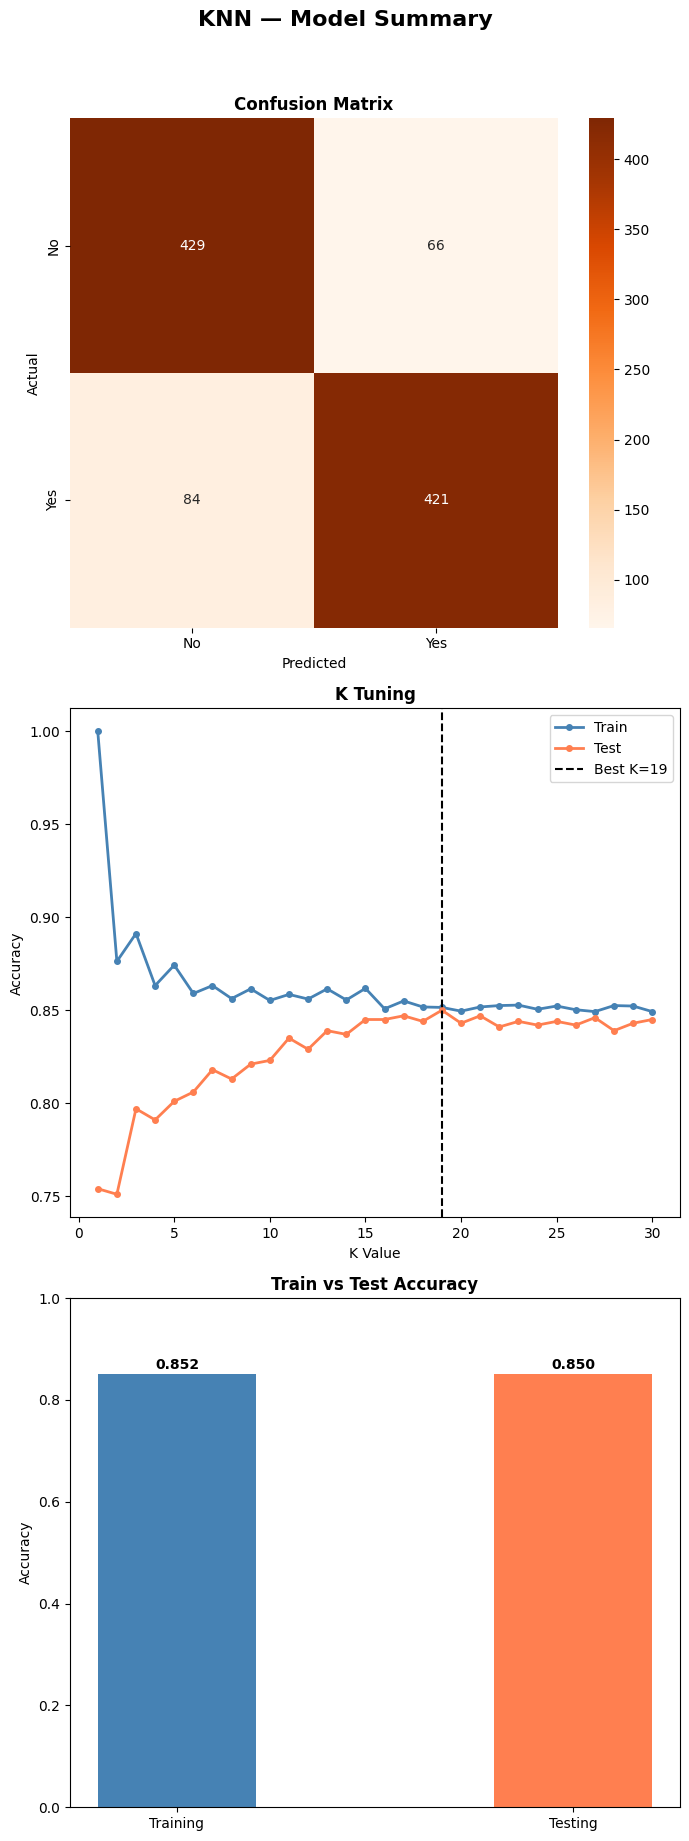

In [28]:
fig, axes = plt.subplots(3, 1, figsize=(7, 18))

# Plot 1 — Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
            xticklabels=['No', 'Yes'],
            yticklabels=['No', 'Yes'])
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Plot 2 — K Tuning
axes[1].plot(k_range, train_scores, marker='o', markersize=4,
             label='Train', color='steelblue', linewidth=2)
axes[1].plot(k_range, test_scores,  marker='o', markersize=4,
             label='Test',  color='coral',     linewidth=2)
axes[1].axvline(best_k, linestyle='--', color='black',
                label=f'Best K={best_k}')
axes[1].set_title('K Tuning', fontweight='bold')
axes[1].set_xlabel('K Value')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

# Plot 3 — Train vs Test
labels = ['Training', 'Testing']
scores = [train_acc, test_acc]
colors = ['steelblue', 'coral']
axes[2].bar(labels, scores, color=colors, width=0.4)
axes[2].set_ylim(0, 1)
axes[2].set_title('Train vs Test Accuracy', fontweight='bold')
axes[2].set_ylabel('Accuracy')
for i, v in enumerate(scores):
    axes[2].text(i, v + 0.01, f'{v:.3f}',
                 ha='center', fontweight='bold')

plt.suptitle('KNN — Model Summary',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()